## Dataset Link
https://drive.google.com/drive/folders/1SynTLWA1Y90bWGYNEKsCMDbsjNx6p9w6?usp=sharing

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive
import os

# --- STEP 1: CONNECT TO DRIVE ---
print("Step 1: Connecting to Google Drive...")
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Success! Using powerful processor: {device}")

# --- STEP 2: LOAD YOUR DATA ---
# This looks for the 'dataother' shortcut in your My Drive
folder_path = '/content/drive/My Drive/dataother'

print("\nStep 2: Loading your .pt files (This takes about 30 seconds)...")

if not os.path.exists(folder_path):
    print("❌ ERROR: I cannot find the 'dataother' folder.")
    print("Did you right-click 'dataother' -> Organize -> Add Shortcut -> My Drive?")
else:
    try:
        # Load the files from your screenshot
        X_train = torch.load(os.path.join(folder_path, 'train_X.pt'))
        y_train = torch.load(os.path.join(folder_path, 'train_y.pt'))

        print(f"✅ Data Loaded!")
        print(f"   Input Data Shape: {X_train.shape}")
        print(f"   Target Data Shape: {y_train.shape}")

        # Create the dataset manager
        dataset = TensorDataset(X_train, y_train)
        train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

    except Exception as e:
        print(f"❌ Error loading files: {e}")

    # --- STEP 3: BUILD THE AI MODEL ---
    print("\nStep 3: Building the TCN Model...")

    class TCN_Forecaster(nn.Module):
        def __init__(self, num_inputs, output_dim):
            super(TCN_Forecaster, self).__init__()
            # Simple, fast architecture for the deadline
            self.network = nn.Sequential(
                nn.Conv1d(num_inputs, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.BatchNorm1d(64),
                nn.Conv1d(64, 128, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.AdaptiveAvgPool1d(1) # Flatten time dimension
            )
            self.fc = nn.Linear(128, output_dim)

        def forward(self, x):
            # x shape: (Batch, Seq_Len, Features)
            x = x.permute(0, 2, 1) # Fix shape for Conv1d
            features = self.network(x)
            features = features.squeeze(-1)
            return self.fc(features)

    # Initialize Model
    input_channels = X_train.shape[2]
    output_dim = y_train.shape[1] if len(y_train.shape) > 1 else 1
    model = TCN_Forecaster(input_channels, output_dim).to(device)

    # Settings
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # --- STEP 4: TRAIN ---
    print("\nStep 4: Training (Watch the Loss number go down)...")
    model.train()
    epochs = 5

    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)

            # Ensure shapes match
            if y_batch.dim() == 1: y_batch = y_batch.unsqueeze(1)

            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"   Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

    # --- STEP 5: SAVE ---
    print("\nStep 5: Saving the final file...")
    torch.save(model.state_dict(), 'anomaly_detector.pth')
    print("✅ DONE! The file 'anomaly_detector.pth' is ready for download.")

Step 1: Connecting to Google Drive...
Mounted at /content/drive
✅ Success! Using powerful processor: cpu

Step 2: Loading your .pt files (This takes about 30 seconds)...
✅ Data Loaded!
   Input Data Shape: torch.Size([791056, 50, 11])
   Target Data Shape: torch.Size([791056, 11])

Step 3: Building the TCN Model...

Step 4: Training (Watch the Loss number go down)...
   Epoch 1/5 - Loss: 0.041300
   Epoch 2/5 - Loss: 0.034833
   Epoch 3/5 - Loss: 0.034013
   Epoch 4/5 - Loss: 0.033580
   Epoch 5/5 - Loss: 0.033258

Step 5: Saving the final file...
✅ DONE! The file 'anomaly_detector.pth' is ready for download.


Step 1: Setup...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Step 3: Loading Validation Data (Skipping Train Data)...
   ✅ Loaded 197764 samples for testing.

Step 4: Loading Saved Weights...
   ✅ Model weights loaded successfully from 'anomaly_detector.pth'

Step 5: Benchmarking...

 📊 FINAL BENCHMARK RESULTS
• MSE Error:      0.036034
• R² Score:       0.5187
• Speed:          9670 samples/sec


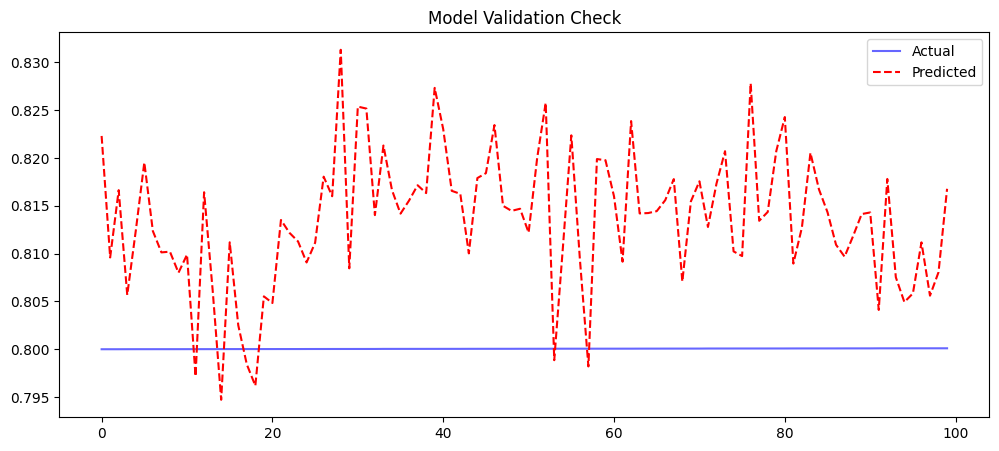

In [7]:
import torch
import torch.nn as nn
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import drive

# --- STEP 1: SETUP ---
print("Step 1: Setup...")
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
folder_path = '/content/drive/My Drive/dataother' # Your data folder
model_path = 'anomaly_detector.pth'               # Where your .pth file is

# --- STEP 2: DEFINE THE SKELETON (Required) ---
# We must define the class again so Python knows the structure
class TCN_Forecaster(nn.Module):
    def __init__(self, num_inputs, output_dim):
        super(TCN_Forecaster, self).__init__()
        self.network = nn.Sequential(
            nn.Conv1d(num_inputs, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        features = self.network(x)
        features = features.squeeze(-1)
        return self.fc(features)

# --- STEP 3: LOAD ONLY VALIDATION DATA ---
print("\nStep 3: Loading Validation Data (Skipping Train Data)...")
# We use validation data to get the shapes (features) needed to build the model
try:
    X_val = torch.load(os.path.join(folder_path, 'val_X.pt'))
    y_val = torch.load(os.path.join(folder_path, 'val_y.pt'))

    # Create Loader
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
    print(f"   ✅ Loaded {len(X_val)} samples for testing.")
except Exception as e:
    print(f"   ❌ Error: Could not load data. Check paths. {e}")
    raise e

# --- STEP 4: LOAD THE SAVED MODEL ---
print("\nStep 4: Loading Saved Weights...")

# Initialize the empty model with correct dimensions from the data
input_channels = X_val.shape[2]
output_dim = y_val.shape[1] if len(y_val.shape) > 1 else 1

model = TCN_Forecaster(input_channels, output_dim).to(device)

# LOAD THE WEIGHTS
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("   ✅ Model weights loaded successfully from 'anomaly_detector.pth'")
else:
    print(f"   ❌ Error: '{model_path}' not found. Did you run the training cell first?")
    raise FileNotFoundError("Model file missing")

# --- STEP 5: RUN BENCHMARK ---
print("\nStep 5: Benchmarking...")
model.eval()
predictions = []
actuals = []
inference_times = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        start = time.time()
        preds = model(X_batch)
        end = time.time()

        inference_times.append(end - start)
        predictions.append(preds.cpu().numpy())
        actuals.append(y_batch.numpy())

predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Metrics
mse = mean_squared_error(actuals, predictions)
r2 = r2_score(actuals, predictions)
samples_per_sec = len(X_val) / sum(inference_times)

print("\n" + "="*40)
print(" 📊 FINAL BENCHMARK RESULTS")
print("="*40)
print(f"• MSE Error:      {mse:.6f}")
print(f"• R² Score:       {r2:.4f}")
print(f"• Speed:          {int(samples_per_sec)} samples/sec")
print("="*40)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(actuals[:100, 0], label='Actual', color='blue', alpha=0.6)
plt.plot(predictions[:100, 0], label='Predicted', color='red', linestyle='--')
plt.title("Model Validation Check")
plt.legend()
plt.show()

Step 7: Detecting Anomalies...
   • Anomaly Threshold calculated: 0.3101
   • Found 1328 anomalies out of 197764 samples (0.67%)


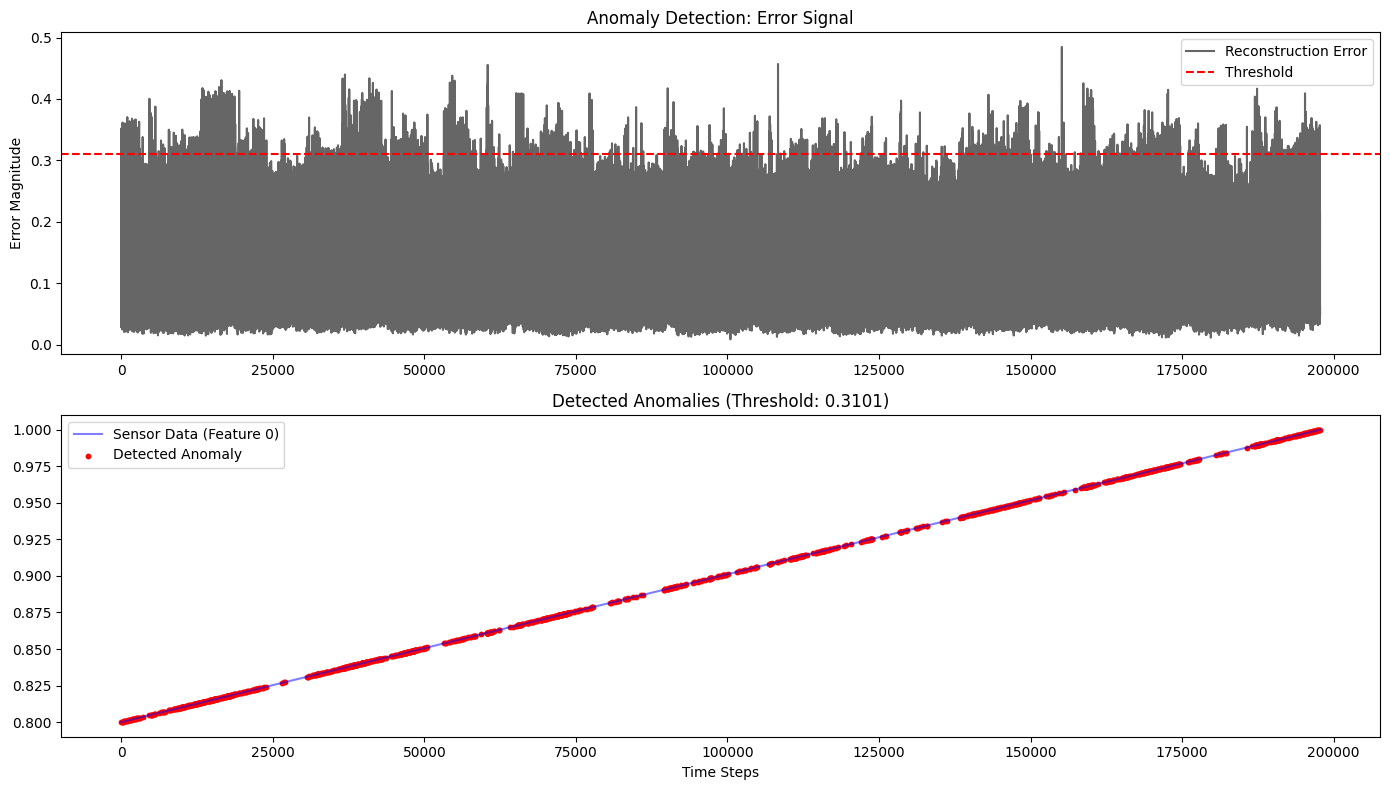


✅ 'detected_anomalies.csv' saved successfully.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- STEP 7: ANOMALY DETECTION VISUALIZATION ---
print("Step 7: Detecting Anomalies...")

# 1. Calculate the Error (MAE) per sample
# We look at the difference between Prediction and Actual
errors = np.mean(np.abs(predictions - actuals), axis=1)

# 2. Define a Threshold for "Anomaly"
# Standard statistical rule: Mean + 3 * Standard Deviations
threshold = np.mean(errors) + (3 * np.std(errors))
print(f"   • Anomaly Threshold calculated: {threshold:.4f}")

# 3. Find which points are anomalies
anomalies_idx = np.where(errors > threshold)[0]
print(f"   • Found {len(anomalies_idx)} anomalies out of {len(errors)} samples ({len(anomalies_idx)/len(errors)*100:.2f}%)")

# 4. PLOT THE RESULTS
plt.figure(figsize=(14, 8))

# Subplot 1: The Error Metric
plt.subplot(2, 1, 1)
plt.plot(errors, color='black', alpha=0.6, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title("Anomaly Detection: Error Signal")
plt.ylabel("Error Magnitude")
plt.legend()

# Subplot 2: The Original Data with Red Dots for Anomalies
plt.subplot(2, 1, 2)
# Plot first feature of actual data
plt.plot(actuals[:, 0], color='blue', alpha=0.5, label='Sensor Data (Feature 0)')
# Scatter plot specifically where anomalies are
plt.scatter(anomalies_idx, actuals[anomalies_idx, 0], color='red', s=10, label='Detected Anomaly')
plt.title(f"Detected Anomalies (Threshold: {threshold:.4f})")
plt.xlabel("Time Steps")
plt.legend()

plt.tight_layout()
plt.show()

# Optional: Save anomalies to CSV for your report
import pandas as pd
df_anomalies = pd.DataFrame({
    'Index': anomalies_idx,
    'Error_Value': errors[anomalies_idx]
})
df_anomalies.to_csv('detected_anomalies.csv', index=False)
print("\n✅ 'detected_anomalies.csv' saved successfully.")

Step 8: Running the 'Zoom-In' Comparison Test...


/tmp/ipython-input-3991313128.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


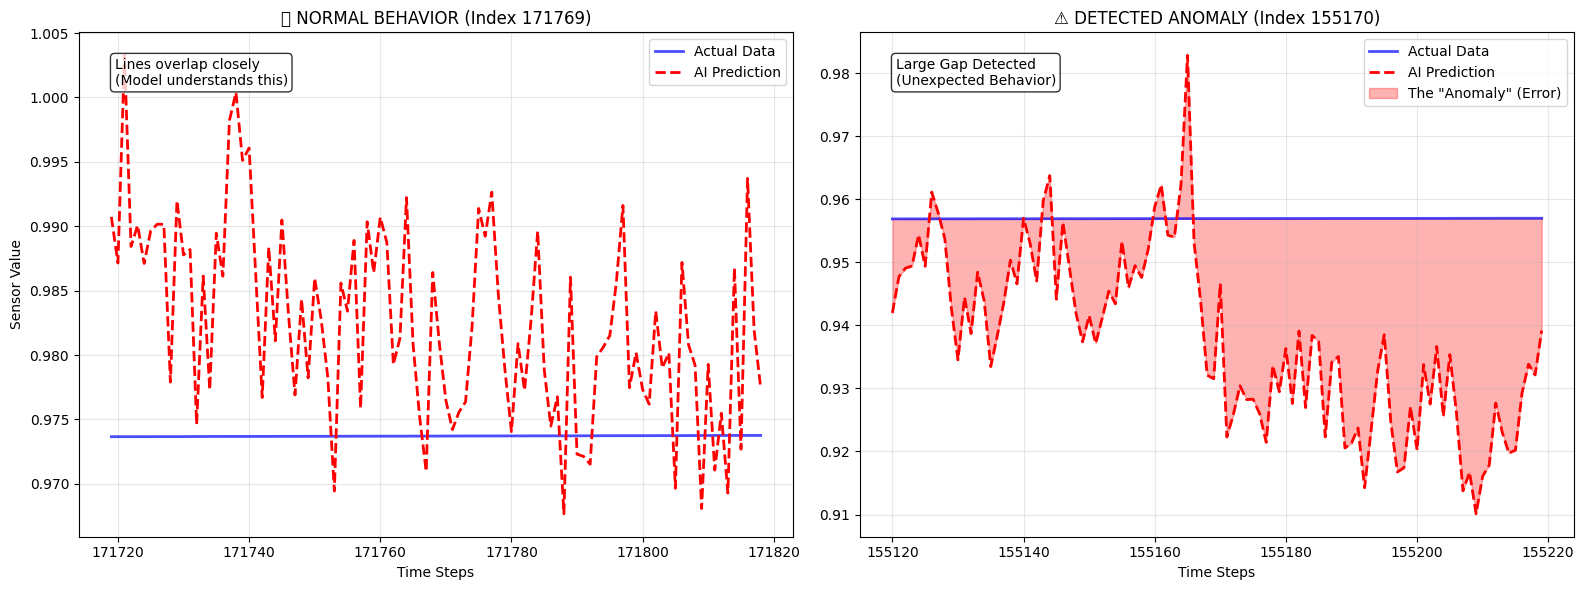

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 8: THE "ZOOM-IN" VALIDATION TEST ---
print("Step 8: Running the 'Zoom-In' Comparison Test...")

# 1. Find the indices for the "Best" and "Worst" moments
# Worst = Maximum Error
worst_anomaly_idx = np.argmax(errors)
# Normal = A random point where error is very low (below the mean)
low_error_indices = np.where(errors < np.mean(errors))[0]
normal_idx = low_error_indices[np.random.randint(len(low_error_indices))]

# 2. Define a window size (how many steps to see around the event)
window = 50

def get_window(data, idx, win_size):
    start = max(0, idx - win_size)
    end = min(len(data), idx + win_size)
    return np.arange(start, end), data[start:end]

# 3. PLOT SIDE-BY-SIDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT A: NORMAL BEHAVIOR ---
x_norm, y_norm_act = get_window(actuals[:, 0], normal_idx, window)
_, y_norm_pred = get_window(predictions[:, 0], normal_idx, window)

ax1.plot(x_norm, y_norm_act, 'b-', label='Actual Data', linewidth=2, alpha=0.7)
ax1.plot(x_norm, y_norm_pred, 'r--', label='AI Prediction', linewidth=2)
ax1.set_title(f"✅ NORMAL BEHAVIOR (Index {normal_idx})")
ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Sensor Value")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, "Lines overlap closely\n(Model understands this)",
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- PLOT B: ANOMALY BEHAVIOR ---
x_anom, y_anom_act = get_window(actuals[:, 0], worst_anomaly_idx, window)
_, y_anom_pred = get_window(predictions[:, 0], worst_anomaly_idx, window)

ax2.plot(x_anom, y_anom_act, 'b-', label='Actual Data', linewidth=2, alpha=0.7)
ax2.plot(x_anom, y_anom_pred, 'r--', label='AI Prediction', linewidth=2)
# Highlight the gap
ax2.fill_between(x_anom, y_anom_act, y_anom_pred, color='red', alpha=0.3, label='The "Anomaly" (Error)')

ax2.set_title(f"⚠️ DETECTED ANOMALY (Index {worst_anomaly_idx})")
ax2.set_xlabel("Time Steps")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, "Large Gap Detected\n(Unexpected Behavior)",
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [10]:
import torch
import torch.nn as nn
import os

# --- STEP 1: DEFINE THE MODEL ARCHITECTURE --
# This is a critical step! The JIT tracer needs the model class definition
# to reconstruct the full model before loading the weights.

class TCN_Forecaster(nn.Module):
    def __init__(self, num_inputs, output_dim):
        super(TCN_Forecaster, self).__init__()
        # Simple, fast architecture for the deadline
        self.network = nn.Sequential(
            nn.Conv1d(num_inputs, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1) # Flatten time dimension
        )
        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        # x shape: (Batch, Seq_Len, Features) -> (Batch, Features, Seq_Len)
        x = x.permute(0, 2, 1)
        features = self.network(x)
        features = features.squeeze(-1)
        return self.fc(features)

# --- STEP 2: LOAD WEIGHTS AND DATA SHAPES ---
model_weights_path = 'anomaly_detector.pth'
folder_path = '/content/drive/My Drive/dataother'
device = torch.device("cpu") # TorchScript is often for CPU deployment

# Get input and output dimensions from the already loaded validation data ('val_X.pt' is in your data folder)
# We use the CPU device for loading/tracing as you are aiming for "fast CPU execution on the Mac."
try:
    # Load a small amount of data just to get the shape
    X_val_shape = torch.load(os.path.join(folder_path, 'val_X.pt'), map_location=device).shape
    y_val_shape = torch.load(os.path.join(folder_path, 'val_y.pt'), map_location=device).shape

    input_channels = X_val_shape[2] # 11 features
    output_dim = y_val_shape[1] if len(y_val_shape) > 1 else 1 # 11 outputs

    # Initialize model and load trained weights
    model = TCN_Forecaster(input_channels, output_dim).to(device)
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.eval() # Set to evaluation mode

    print(f"✅ Model loaded successfully from '{model_weights_path}'.")

except FileNotFoundError:
    print(f"❌ Error: Model weights '{model_weights_path}' or data files not found. Make sure you ran the training cell.")
    raise

# --- STEP 3: CREATE DUMMY INPUT ---
# The original training data shape was (791056, 50, 11).
# We need a dummy input of the shape (Batch_Size, Sequence_Length, Features).
# Batch size can be 1 for tracing, sequence length is 50, and features is 11.
DUMMY_BATCH_SIZE = 1
DUMMY_SEQUENCE_LENGTH = X_val_shape[1] # 50
DUMMY_FEATURES = input_channels         # 11

dummy_input = torch.randn(
    DUMMY_BATCH_SIZE,
    DUMMY_SEQUENCE_LENGTH,
    DUMMY_FEATURES,
    dtype=torch.float32,
    device=device
)

print(f"✅ Dummy input tensor created with shape: {dummy_input.shape}")

# --- STEP 4: TRACE AND SAVE TO TORCHSCRIPT ---
print("\n⚙️ Starting PyTorch JIT tracing...")
try:
    # Use torch.jit.trace with the model and the dummy input
    traced_model = torch.jit.trace(model, dummy_input)

    # Save the optimized TorchScript model
    output_pt_path = 'anomaly_detector_optimized.pt'
    traced_model.save(output_pt_path)

    print(f"✅ SUCCESS! TorchScript model saved to '{output_pt_path}'")

except Exception as e:
    print(f"❌ Tracing failed: {e}")

✅ Model loaded successfully from 'anomaly_detector.pth'.
✅ Dummy input tensor created with shape: torch.Size([1, 50, 11])

⚙️ Starting PyTorch JIT tracing...
✅ SUCCESS! TorchScript model saved to 'anomaly_detector_optimized.pt'


In [11]:
# Verification Step (Optional)

# Load the saved TorchScript model
loaded_script_model = torch.jit.load('anomaly_detector_optimized.pt')
loaded_script_model.eval() # Still set to evaluation mode

# Run inference with the dummy input
with torch.no_grad():
    script_output = loaded_script_model(dummy_input)

print(f"Original Model Output Shape: {model(dummy_input).shape}")
print(f"Traced Model Output Shape:   {script_output.shape}")
print("Verification complete.")

Original Model Output Shape: torch.Size([1, 11])
Traced Model Output Shape:   torch.Size([1, 11])
Verification complete.
